In [1]:
# import os
# import shutil

# # 1. Try to unmount the read-only system mount
# # We use os.system because ! commands are jupyter-specific, but valid here
# ret = os.system("umount -l /kaggle/input") 
# if ret != 0:
#     print("Unmount failed or not needed (maybe not mounted yet)")

# # 2. Check if it still exists and is a directory
# if os.path.exists('/kaggle/input'):
#     # If it is still a mount point, this might fail, but if unmount worked, this clears it
#     try:
#         shutil.rmtree('/kaggle/input')
#     except Exception as e:
#         print(f"Could not remove /kaggle/input: {e}")

# # 3. Create fresh, writable directories
# os.makedirs('/kaggle/input', exist_ok=True)
# os.makedirs('/kaggle/working', exist_ok=True)

# print("Directories /kaggle/input and /kaggle/working are ready and writable.")

In [2]:
# import kagglehub
# kagglehub.login()

In [3]:
# import kagglehub
# import os



# datasets = [
#     'maanav0114/harps-n-dataset',
# ]

# for dataset in datasets:
#     # Download
#     path = kagglehub.dataset_download(dataset)

#     # Symlink
#     data_dir = dataset.split('/')
#     os.makedirs(f'/kaggle/input/{data_dir[0]}', exist_ok=True)
#     target = f'/kaggle/input/{data_dir[1]}'
#     if not os.path.exists(target):
#         os.symlink(path, target)
#         print(f"Linked to {target}")

In [4]:
# from pathlib import Path
# from astropy.io import fits
# import pandas as pd



# # Adapted to the corresponding names in the HARPS dataset for easier preprocessing
# columns = ['main_id_simbad', 'drs_bjd', 'drs_ccf_rvc', 'drs_dvrms']
# df = pd.DataFrame(columns = columns)



# directory = Path("/kaggle/input/harps-n-dataset/keck_vels/keck_vels")

# file_count = 0
# for file in directory.iterdir():
#     if file.is_file():
#         rows = []
#         with open(str(file), 'r') as f:
#             content = f.read()
#             # print(f'{content}\n\n')
            
#             for i in range(len(content.split('\n'))):
#                 row = content.split('\n')[i].split(" ")
#                 row = [feature for feature in row if feature != '']
                
#                 if len(row) != 0:
#                     star = str(file.name).split(".")[0].split("_")[0]
#                     row.insert(0, star)
#                     for k in range(4):
#                         row.pop(-1)
                        
#                     rows.append(row)

#         for row in rows:
#             df.loc[len(df)] = row

#         # if file_count % 10 == 0:
#         # print(f"On file {file_count}")
#         # print(f'Df len: {len(df)}\n\n')
#         file_count += 1

# df

In [5]:
import pandas as pd



df = pd.DataFrame(pd.read_csv('/kaggle/input/harps-n-dataset/preprocessed_HIRES_data.csv'))
df

,main_id_simbad,drs_bjd,drs_ccf_rvc,drs_dvrms
0,LHS462,2.451705e+06,6.75,3.37
1,LHS462,2.452008e+06,-3.38,4.75
2,LHS462,2.452099e+06,-1.84,3.15
3,LHS462,2.452163e+06,0.89,3.90
4,LHS462,2.452391e+06,-10.86,3.93
...,...,...,...,...
75057,HD1770,2.455404e+06,0.00,0.92
75058,HD1770,2.455467e+06,6.29,0.97
75059,HD1770,2.455585e+06,-34.73,1.15
75060,HD1770,2.456164e+06,-42.43,1.11


In [6]:
from astropy.io import fits
import pandas as pd



with fits.open('/kaggle/input/harps-n-dataset/ADP.2023-12-04T15_16_53.464.fits') as data:
    # Convert to native byte order immediately
        fits_data = data[1].data
        
        # Create DataFrame with native byte order arrays
        df_dict = {}
        for name in fits_data.dtype.names:
            arr = fits_data[name]
            # Convert to native byte order
            if not arr.dtype.isnative:
                arr = arr.astype(arr.dtype.newbyteorder('='))
            df_dict[name] = arr
        
        harps_df = pd.DataFrame(df_dict)



harps_df

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,adp_dpid,raw_dpid,progid,dpr_tech,dpr_type,ins_mode,tel_object,tel_targ_alpha,tel_targ_delta,date_obs,...,pmdec_simbad,pmra_err_simbad,pmdec_err_simbad,pm_err_pa_simbad,Bmag_simbad,Vmag_simbad,Jmag_simbad,Hmag_simbad,Kmag_simbad,angDist_simbad
0,ADP.2022-01-26T01:03:07.064,HARPS.2003-09-19T08:30:25.080,60.A-9036(A),"ECHELLE,ABSORPTION-CELL","STAR,DARK,G8V",HAM,HD10700,26.021250,-15.939556,2003-09-19T08:30:25.079,...,854.963,0.181,0.088,90,4.220,3.500,2.140,1.720,1.680,16.460407
1,ADP.2014-09-29T13:27:18.277,HARPS.2003-10-24T00:54:57.425,60.A-9036(A),ECHELLE,"STAR,WAVE,G5IV/V",HAM,HD207700,328.688333,-73.438472,2003-10-24T00:54:57.425,...,-437.609,0.018,0.022,90,8.120,7.430,6.234,5.933,5.794,0.046123
2,ADP.2014-09-29T13:27:13.397,HARPS.2003-10-24T01:17:16.261,60.A-9036(A),ECHELLE,"STAR,DARK,NONE",HAM,HR7703,302.795833,-36.101111,2003-10-24T01:17:16.261,...,-1576.732,0.100,0.073,90,5.440,5.320,NaN,NaN,NaN,11.383005
3,ADP.2014-09-29T13:27:17.630,HARPS.2003-10-24T01:20:47.653,60.A-9036(A),ECHELLE,"STAR,DARK,NONE",HAM,HR7703,302.795833,-36.101111,2003-10-24T01:20:47.653,...,-1576.732,0.100,0.073,90,5.440,5.320,NaN,NaN,NaN,11.383005
4,ADP.2014-09-29T13:27:00.867,HARPS.2003-10-24T01:24:18.926,60.A-9036(A),ECHELLE,"STAR,DARK,NONE",HAM,HR7703,302.795833,-36.101111,2003-10-24T01:24:18.926,...,-1576.732,0.100,0.073,90,5.440,5.320,NaN,NaN,NaN,11.383005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289838,ADP.2023-05-31T01:00:58.755,HARPS.2023-05-30T00:44:32.997,60.A-9709(G),ECHELLE,"STAR,DARK,NONE",HAM,HR5501,221.376042,0.717417,2023-05-30T00:44:32.997,...,-8.231,0.164,0.172,90,5.656,5.665,5.619,5.619,5.602,0.858292
289839,ADP.2023-05-31T01:00:58.757,HARPS.2023-05-30T00:54:35.181,60.A-9709(G),ECHELLE,"STAR,DARK,NONE",EGGS,HR5501,221.376042,0.717417,2023-05-30T00:54:35.181,...,-8.231,0.164,0.172,90,5.656,5.665,5.619,5.619,5.602,0.858292
289840,ADP.2023-05-31T01:00:58.759,HARPS.2023-05-30T00:57:37.401,60.A-9709(G),ECHELLE,"STAR,DARK,NONE",EGGS,HR5501,221.376042,0.717417,2023-05-30T00:57:37.401,...,-8.231,0.164,0.172,90,5.656,5.665,5.619,5.619,5.602,0.858292
289841,ADP.2023-05-31T01:00:58.761,HARPS.2023-05-30T01:00:40.402,60.A-9709(G),ECHELLE,"STAR,DARK,NONE",EGGS,HR5501,221.376042,0.717417,2023-05-30T01:00:40.401,...,-8.231,0.164,0.172,90,5.656,5.665,5.619,5.619,5.602,0.858292


In [7]:
harps_stars = list(set(list(harps_df['main_id_simbad'])))
hires_stars = list(set(list(df['main_id_simbad'])))

for star in harps_stars:
    idx = harps_stars.index(star)
    
    star = star.split(" ")
    star = "".join(star)
    star = star.lower()

    harps_stars[idx] = star

# for star in hires_stars:
#     idx = hires_stars.index(star)
    
#     star = star.split(" ")
#     star = "".join(star)
#     star = star.lower()

#     hires_stars[idx] = star


print(len(df))
for star in hires_stars:
    mod_star = star.split(" ")
    mod_star = "".join(star)
    mod_star = star.lower()
    
    if mod_star in harps_stars:
        df = df[df['main_id_simbad'] != star]
        

print(len(df))

75062
56827


In [8]:
df.describe()

,drs_bjd,drs_ccf_rvc,drs_dvrms
count,5.682700e+04,56827.000000,56827.000000
mean,2.454933e+06,-12.251663,1.962147
std,1.960438e+03,1063.381590,4.266271
min,2.450276e+06,-46649.640000,0.010000
25%,2.453694e+06,-5.110000,1.200000
50%,2.455164e+06,0.000000,1.410000
75%,2.456148e+06,4.740000,1.770000
max,2.458919e+06,41546.190000,373.170000


In [9]:
exo_catalog = pd.DataFrame(pd.read_csv('/kaggle/input/harps-n-dataset/catalog_of_exoplanets.csv'))
exo_catalog

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,name,planet_status,mass,mass_error_min,mass_error_max,mass_sini,mass_sini_error_min,mass_sini_error_max,radius,radius_error_min,...,star_sp_type,star_age,star_age_error_min,star_age_error_max,star_teff,star_teff_error_min,star_teff_error_max,star_detected_disc,star_magnetic_field,star_alternate_names
0,109 Psc b,Confirmed,5.74300,0.28900,0.28900,6.38300,0.07800,0.07800,1.152,NaN,...,G5 IV,6.900,0.600,0.600,5600.00,80.00000,80.00000,NaN,NaN,HD 10697
1,109 Tau b,Candidate,16.00000,NaN,NaN,16.00000,NaN,NaN,NaN,NaN,...,G8III,0.600,0.050,0.050,5012.07,3.91874,3.91874,NaN,NaN,"n Tau, HD 34559"
2,110 Vir b,Candidate,1.60000,0.10000,0.10000,NaN,NaN,NaN,NaN,NaN,...,K0IIIb,3.330,1.900,1.900,4650.00,NaN,NaN,NaN,NaN,HIP 73620
3,112 Psc b,Confirmed,0.03300,0.00500,0.00500,0.03300,0.00500,0.00500,NaN,NaN,...,G0IV,NaN,NaN,NaN,5986.00,105.43700,105.43700,NaN,NaN,HD 12235
4,112 Psc c,Confirmed,9.86600,1.78100,1.78100,NaN,NaN,NaN,NaN,NaN,...,G0IV,NaN,NaN,NaN,5986.00,105.43700,105.43700,NaN,NaN,HD 12235
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1544,YZ Cet c,Confirmed,0.00359,0.00035,0.00035,0.00359,0.00035,0.00035,NaN,NaN,...,M4.5,4.000,0.600,0.600,3056.00,60.00000,60.00000,NaN,NaN,NaN
1545,YZ Cet d,Confirmed,0.00343,0.00038,0.00038,0.00343,0.00038,0.00038,NaN,NaN,...,M4.5,4.000,0.600,0.600,3056.00,60.00000,60.00000,NaN,NaN,NaN
1546,YZ Cet e,Candidate,0.00149,0.00030,0.00030,0.00149,0.00030,0.00030,NaN,NaN,...,M4.5,4.000,0.600,0.600,3056.00,60.00000,60.00000,NaN,NaN,NaN
1547,zet Her Ab,Candidate,50.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,G0IV,3.380,NaN,NaN,5795.47,NaN,NaN,NaN,NaN,40 Her


In [10]:
confirmed_stars = list(set(list(exo_catalog[exo_catalog['planet_status'] == 'Confirmed']['star_name'].dropna())))
# confirmed.extend(list(set(list(exo_catalog[exo_catalog['planet_status'] == 'Confirmed']['star_alternate_names']))))
# print(confirmed_stars)
alternate_names = list(set(list(exo_catalog[exo_catalog['planet_status'] == 'Confirmed']['star_alternate_names'].dropna())))
for star in alternate_names:
    star = star.split(",")
    confirmed_stars.extend(star)

for star in confirmed_stars:
    idx = confirmed_stars.index(star)
    
    star = star.split(" ")
    star = "".join(star)
    confirmed_stars[idx] = star.lower()

confirmed_stars[:10]

['bd-004475',
 'chisco',
 'hd114613',
 'toi-1634a',
 'hd63454',
 'hd210193',
 'hd210702a',
 'hd19615',
 'hip11915',
 'hd96992']

In [11]:
print(len(confirmed_stars))

1563


In [12]:
candidate_stars = list(set(list(exo_catalog[exo_catalog['planet_status'] == 'Candidate']['star_name'].dropna())))
# confirmed.extend(list(set(list(exo_catalog[exo_catalog['planet_status'] == 'Confirmed']['star_alternate_names']))))
# print(confirmed_stars)
alternate_names = list(set(list(exo_catalog[exo_catalog['planet_status'] == 'Candidate']['star_alternate_names'].dropna())))
for star in alternate_names:
    star = star.split(",")
    candidate_stars.extend(star)

for star in candidate_stars:
    idx = candidate_stars.index(star)
    
    star = star.split(" ")
    star = "".join(star)
    candidate_stars[idx] = star.lower()

confirmed_stars.extend(candidate_stars)
confirmed_stars[:10]

['bd-004475',
 'chisco',
 'hd114613',
 'toi-1634a',
 'hd63454',
 'hd210193',
 'hd210702a',
 'hd19615',
 'hip11915',
 'hd96992']

In [13]:
print(len(confirmed_stars))

1931


In [14]:
stars = list(set(list(df['main_id_simbad'])))


exoplanet_stars = []
for star in stars:
    idx = stars.index(star)
    
    star = star.lower().split(" ")
    star = str("".join(star))
    if star in confirmed_stars:
        exoplanet_stars.append(stars[idx])



df['has_exoplanets'] = 0
for i in range(len(df)):
    if df.iloc[i]['main_id_simbad'] in exoplanet_stars:
        df.loc[i, 'has_exoplanets'] = 1

df.describe()

,drs_bjd,drs_ccf_rvc,drs_dvrms,has_exoplanets
count,5.682700e+04,56827.000000,56827.000000,60775.000000
mean,2.454933e+06,-12.251663,1.962147,0.232546
std,1.960438e+03,1063.381590,4.266271,0.422459
min,2.450276e+06,-46649.640000,0.010000,0.000000
25%,2.453694e+06,-5.110000,1.200000,0.000000
50%,2.455164e+06,0.000000,1.410000,0.000000
75%,2.456148e+06,4.740000,1.770000,0.000000
max,2.458919e+06,41546.190000,373.170000,1.000000


In [15]:
df.to_csv('/kaggle/working/preprocessed_HIRES_data.csv', index = False)

In [16]:
# df = df.dropna()
df[df['has_exoplanets'] == 1]

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,main_id_simbad,drs_bjd,drs_ccf_rvc,drs_dvrms,has_exoplanets
197,HD217591,2.454319e+06,-19.36,1.87,1.0
198,HD217591,2.454400e+06,-14.32,2.06,1.0
199,HD217591,2.454457e+06,0.63,1.91,1.0
200,HD217591,2.454675e+06,10.22,2.00,1.0
201,HD217591,2.454725e+06,13.70,1.90,1.0
...,...,...,...,...,...
54064,NaN,NaN,NaN,NaN,1.0
54065,NaN,NaN,NaN,NaN,1.0
55944,NaN,NaN,NaN,NaN,1.0
55945,NaN,NaN,NaN,NaN,1.0


In [17]:
filtered = df[df['main_id_simbad'] == 'HD18803']
filtered = filtered.dropna(subset = ['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])

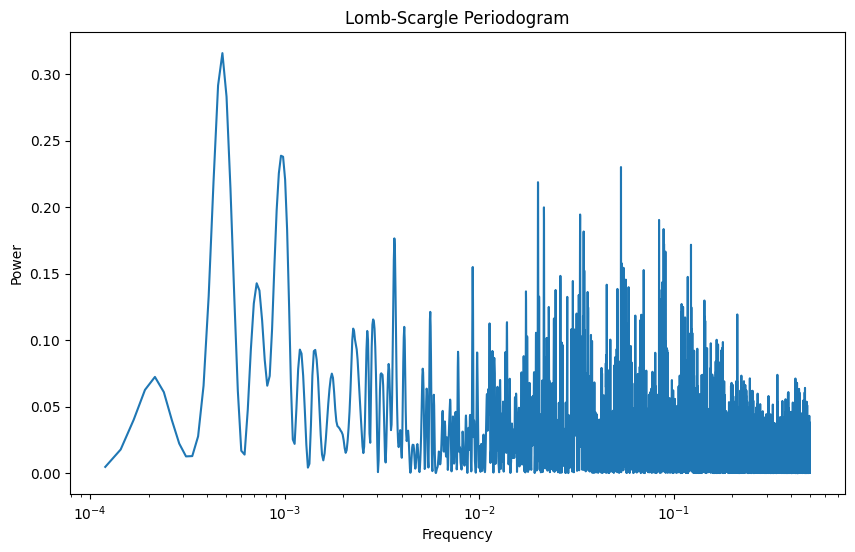

In [18]:
from astropy.timeseries import LombScargle
import numpy as np
import matplotlib.pyplot as plt
from astropy.stats import sigma_clip



time = np.array(filtered['drs_bjd'])
rad_vel = np.array(filtered['drs_ccf_rvc'])
uncertainty = np.array(filtered['drs_dvrms'])

# cleaning
rv_masked = sigma_clip(rad_vel, sigma=10, maxiters=5)
mask = ~rv_masked.mask

time = time[mask]
rad_vel = rad_vel[mask]
uncertainty = uncertainty[mask]


baseline = np.max(time) - np.min(time)
min_freq = 1 / baseline
max_freq = 1 / 2.0


periodogram = LombScargle(time, rad_vel, uncertainty)
frequency, power = periodogram.autopower(minimum_frequency = min_freq, maximum_frequency = max_freq)



plt.figure(figsize=(10, 6))
plt.plot(frequency, power, label="Lomb-Scargle Power")
plt.xscale('log')
plt.xlabel('Frequency')
plt.ylabel('Power')
plt.title('Lomb-Scargle Periodogram')
# plt.vlines(x = 1.4285870439890967e-05, ymin = 0, ymax = 0.07, color = 'r')
plt.show()

In [19]:
!pip install pyts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 24.7 MB/s eta 0:00:00


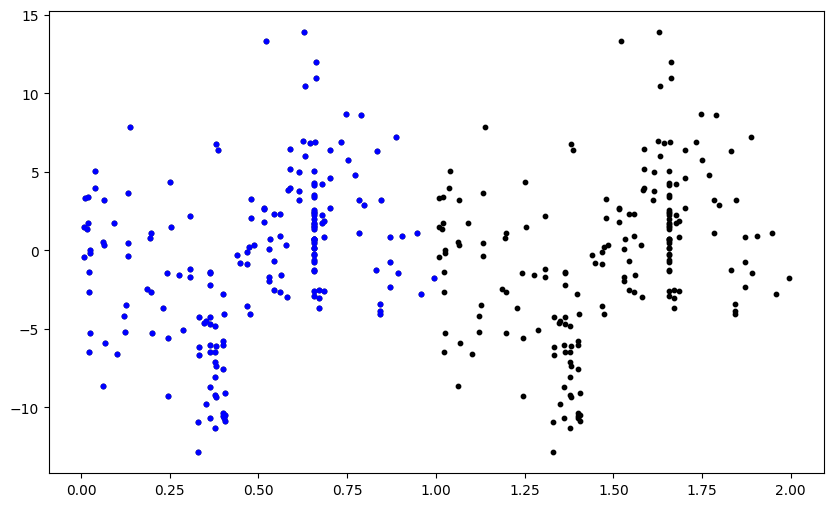

In [20]:
from astropy.timeseries import TimeSeries
from astropy.time import Time
import astropy.units as u



best_freq_idx = np.argmax(power)
best_freq = frequency[best_freq_idx]
best_period = 1 / best_freq


phase = ((time - time[0]) % best_period) / best_period

shift_margin = 0.2
random_shift = np.random.uniform(-shift_margin, shift_margin)
phase = (phase + random_shift) % 1.0

sort_indices = np.argsort(phase)
phase_sorted = phase[sort_indices]
rv_sorted = rad_vel[sort_indices]

phase_shifted = np.concatenate([phase_sorted, phase_sorted + 1])
rv_shifted = np.concatenate([rv_sorted, rv_sorted])

plt.figure(figsize = (10, 6))
plt.scatter(phase_shifted, rv_shifted, color='k', s=10)
plt.scatter(phase_sorted, rv_sorted, color='b', s=10, label='Folded Data')

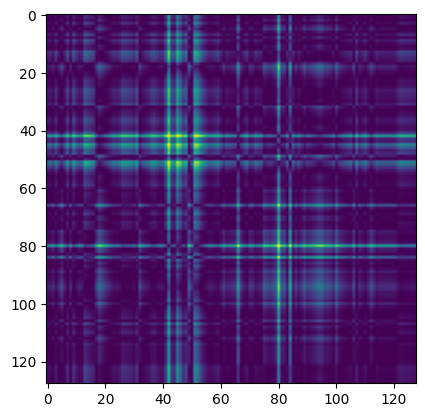

In [21]:
from pyts.image import GramianAngularField



image_resolution = 128
fixed_phase_grid = np.linspace(0, 1, image_resolution)

rv_interpolated = np.interp(fixed_phase_grid, phase_sorted, rv_sorted)
gaf = GramianAngularField(method = 'summation', image_size = image_resolution)
image = gaf.fit_transform(rv_interpolated.reshape(1, -1))[0]


plt.imshow(image)

In [22]:
# from pyts.image import GramianAngularField



# a, b = -1, 1
# frequency = ((frequency - frequency.min()) * (b - a)) / (frequency.max() - frequency.min())
# power = ((power - power.min()) * (b - a)) / (power.max() - power.min())

# gaf = GramianAngularField(method = 'summation', image_size = 24)
# image = gaf.fit_transform(power.reshape(1, -1))[0]

# plt.imshow(image)
# plt.colorbar()
# plt.show()

In [23]:
df = df.dropna(subset = ['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
images = pd.DataFrame(columns = ['star', 'image', 'label'])
images['image'] = images['image'].astype(object)

# columns = ['star']
# for i in range(0, 100):
#     columns.append(f'image{i}')
# columns.append('label')

# images = pd.DataFrame(columns = columns)

images['star'] = list(set(df['main_id_simbad']))
images.head()

,star,image,label
0,HIP79431,NaN,NaN
1,HD92945,NaN,NaN
2,VULCAN8842,NaN,NaN
3,HD93864,NaN,NaN
4,HIP67164,NaN,NaN


In [24]:
from astropy.timeseries import LombScargle
import numpy as np
import matplotlib.pyplot as plt



for i in range(0, len(images)):
    try:
        star = str(images.loc[i, 'star'])
        filtered = df[df['main_id_simbad'] == star]
        if len(filtered) < 2:
            pass
        else:
            time = np.array(filtered['drs_bjd'])
            rad_vel = np.array(filtered['drs_ccf_rvc'])
            uncertainty = np.array(filtered['drs_dvrms'])
            
            # cleaning
            rv_masked = sigma_clip(rad_vel, sigma=10, maxiters=5)
            mask = ~rv_masked.mask
            
            time = time[mask]
            rad_vel = rad_vel[mask]
            uncertainty = uncertainty[mask]
            
            
            baseline = np.max(time) - np.min(time)
            min_freq = 1 / baseline
            max_freq = 1 / 2.0
            
            
            periodogram = LombScargle(time, rad_vel, uncertainty)
            frequency, power = periodogram.autopower(minimum_frequency = min_freq, maximum_frequency = max_freq, method = "fastchi2")
    
    
    
            best_freq_idx = np.argmax(power)
            best_freq = frequency[best_freq_idx]
            best_period = 1 / best_freq
            
            
            phase = ((time - time[0]) % best_period) / best_period

            shift_margin = 0.2
            random_shift = np.random.uniform(-shift_margin, shift_margin)
            phase = (phase + random_shift) % 1.0
            
            sort_indices = np.argsort(phase)
            phase_sorted = phase[sort_indices]
            rv_sorted = rad_vel[sort_indices]
        
        
        
            # a, b = -1, 1
            # frequency = ((frequency - frequency.min()) * (b - a)) / (frequency.max() - frequency.min())
            # power = ((power - power.min()) * (b - a)) / (power.max() - power.min())
            
            # gaf = GramianAngularField(method = 'summation', image_size = 24)
            # image = gaf.fit_transform(power.reshape(1, -1))[0]
    
            image_resolution = 128
            fixed_phase_grid = np.linspace(0, 1, image_resolution)
            
            rv_interpolated = np.interp(fixed_phase_grid, phase_sorted, rv_sorted)
            gaf = GramianAngularField(method = 'summation', image_size = image_resolution)
            image = gaf.fit_transform(rv_interpolated.reshape(1, -1))[0]
    
    
    
        # for i in range(0, 100):
        #     images.loc[i, (f'image{i}')] = list(list(image)[i])
        
            images.at[i, 'image'] = image
            images.loc[i, 'label'] = list(filtered['has_exoplanets'])[0]
                
        if i % 100 == 0:
            print(i)
                
    except Exception as e:
        print(e)
        print(i)
        print(image)
        print(image.shape)
        print(star)
        # break
        continue
    # break

0
index 0 is out of bounds for axis 0 with size 0
52
[[-0.60194769 -0.60194769 -0.46353944 ... -0.77508884 -0.63875141
  -0.63875141]
 [-0.60194769 -0.60194769 -0.46353944 ... -0.77508884 -0.63875141
  -0.63875141]
 [-0.46353944 -0.46353944 -0.31269894 ... -0.66156459 -0.50460292
  -0.50460292]
 ...
 [-0.77508884 -0.77508884 -0.66156459 ... -0.90345996 -0.80388123
  -0.80388123]
 [-0.63875141 -0.63875141 -0.50460292 ... -0.80388123 -0.67414819
  -0.67414819]
 [-0.63875141 -0.63875141 -0.50460292 ... -0.80388123 -0.67414819
  -0.67414819]]
(128, 128)
HIP18774
index 0 is out of bounds for axis 0 with size 0
88
[[-0.94590311 -0.94590311 -0.94590311 ...  0.16446412  0.16446412
   0.16446412]
 [-0.94590311 -0.94590311 -0.94590311 ...  0.16446412  0.16446412
   0.16446412]
 [-0.94590311 -0.94590311 -0.94590311 ...  0.16446412  0.16446412
   0.16446412]
 ...
 [ 0.16446412  0.16446412  0.16446412 ...  1.          1.
   1.        ]
 [ 0.16446412  0.16446412  0.16446412 ...  1.          1.
   1.

1387
251
1136
star                                               HD98219
image    [[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,...
label                                                  0.0
Name: 284, dtype: object


/tmp/ipykernel_13/1099188008.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  iamge = images.iloc[idx][1]


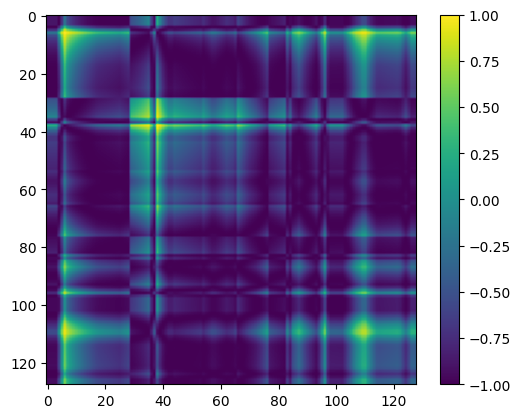

In [25]:
images = images.dropna(subset = ['image'])

print(len(images))
print(len(images[images['label'] == 1]))
print(len(images[images['label'] == 0]))



idx = 277
iamge = images.iloc[idx][1]
print(images.iloc[idx])
plt.imshow(image)
plt.colorbar()

In [26]:
# images.to_csv('/kaggle/working/data.csv', index = False)
images.to_pickle('/kaggle/working/data.pkl')
print("done")

done
